# Limitations of Amplitude Encoding on Quantum Classification (AA_study)

This implementation is based on prior work by [Wang *et al.*](https://arxiv.org/abs/2503.01545).

This notebook will demonstrate the usage of the models implemented in the paper with:
- A simple synthetic dataset classification.
- A binary MNIST classification

## 0. Setup and imports

In [23]:
import sys
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import merlin as ML

REPO_ROOT =  Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings("ignore")

from papers.AA_study.lib.qlayers import amplitude_encoding_simple,angle_encoding_simple,PhotonicQCNN
from papers.AA_study.lib.qiskit_models import qiskit_QCNN,single_qubit_model

from papers.AA_study.utils.datasets import get_data_loader,generate_fig_3_dataset,get_binary_dataset
from papers.AA_study.utils.utils import basic_model_training,evaluate_model,normalize_features


## 1. Classifying a simple dataset

Here we will classify the dataset presented in figure 3 of the paper.

For class 1, $x_1$ follows the uniform distribution $\mathcal{U}[-3,-1]$ and $x_2$ follows the normal distribution $\mathcal{N}(-2,1)$. For class 2, $x_1$ follows the uniform distribution $\mathcal{U}[1,3]$ and $x_2$ follows the normal distribution $\mathcal{N}(2,1)$.

Here is a quick plot of the dataset

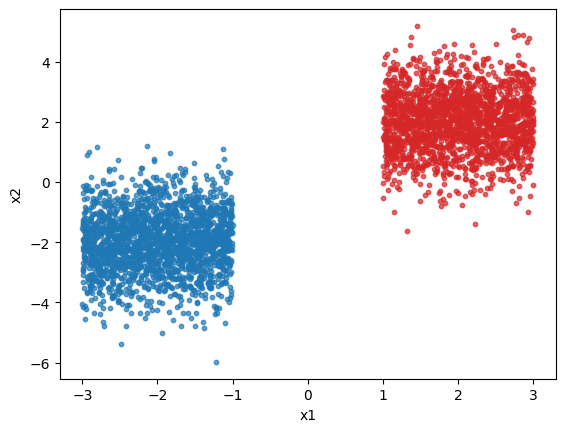

In [6]:
dataset=generate_fig_3_dataset(shuffle=False)
class_1=dataset.tensors[0][:2000]
class_2=dataset.tensors[0][2000:]

plt.scatter(class_1[:, 0], class_1[:, 1], s=10, color="tab:blue", alpha=0.7)
plt.scatter(class_2[:, 0], class_2[:, 1], s=10, color="tab:red", alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Classify the dataset

With one or two qubits models presented in the [ReadMe](README.md)'s sections *Their framework* and *Difference in framework*, lets classify the dataset plotted earlier.

We will use the `utils`' basic_model_training to train the model. This function is a basic training procedure for classifiers.

### Get a data loader

A dataloader is the easiest way to store the data for clssification processes. A `utils`' function can be used to tranform the data into that type easily.

In [ ]:
fig3_dataset=generate_fig_3_dataset()
fig3_dataloader=get_data_loader(fig3_dataset,batch_size=50)

### Gate-based model

We can define the number of layers in the model and if to return logits instead of state probabilities as the forward's output.

Epoch 1 had a loss of 0.7061422325670719 and accuracy of 0.498
Epoch 2 had a loss of 0.6939442999660969 and accuracy of 0.5115
Epoch 3 had a loss of 0.6948529876768589 and accuracy of 0.5015
Epoch 4 had a loss of 0.6948462627828121 and accuracy of 0.505
Epoch 5 had a loss of 0.6944147668778896 and accuracy of 0.5125
Epoch 6 had a loss of 0.693415766209364 and accuracy of 0.509
Epoch 7 had a loss of 0.6932235658168793 and accuracy of 0.5135
Epoch 8 had a loss of 0.6940710112452507 and accuracy of 0.49675
Epoch 9 had a loss of 0.69556565284729 and accuracy of 0.5055
Epoch 10 had a loss of 0.6934751152992249 and accuracy of 0.5065
Epoch 11 had a loss of 0.6931014791131019 and accuracy of 0.51375
Epoch 12 had a loss of 0.6945785991847515 and accuracy of 0.504
Epoch 13 had a loss of 0.6935636162757873 and accuracy of 0.50575
Epoch 14 had a loss of 0.6946803964674473 and accuracy of 0.50925
Epoch 15 had a loss of 0.6944460511207581 and accuracy of 0.50525
Epoch 16 had a loss of 0.69368543550

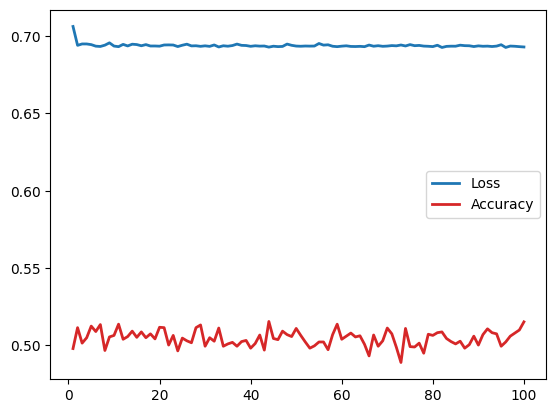

In [ ]:
gate_based_model=single_qubit_model(num_layers=10)

gate_based_model, accuracy_per_epoch, loss_per_epoch=basic_model_training(gate_based_model,fig3_dataloader,num_epochs=100)

epochs=[i for i in range(1,101)]
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()

### Amplitude encoding MerLin model

This model needs the number of features in input. It is possible to change the number of layers in the circuit, the measurement strategy for a different output and, if necessary, change the ouptut dimension (to fit with the number of classes) with num_classes.

Epoch 1 had a loss of 0.6960322268307209 and accuracy of 0.49675
Epoch 2 had a loss of 0.6941687576472759 and accuracy of 0.50675
Epoch 3 had a loss of 0.6945003733038903 and accuracy of 0.50475
Epoch 4 had a loss of 0.6938988275825977 and accuracy of 0.5055
Epoch 5 had a loss of 0.6938523173332214 and accuracy of 0.50625
Epoch 6 had a loss of 0.6950773373246193 and accuracy of 0.50775
Epoch 7 had a loss of 0.695726216584444 and accuracy of 0.499
Epoch 8 had a loss of 0.6944349594414234 and accuracy of 0.49825
Epoch 9 had a loss of 0.6964445509016514 and accuracy of 0.50125
Epoch 10 had a loss of 0.694699154049158 and accuracy of 0.49725
Epoch 11 had a loss of 0.6951734885573387 and accuracy of 0.5
Epoch 12 had a loss of 0.6942506253719329 and accuracy of 0.51325
Epoch 13 had a loss of 0.6962647162377834 and accuracy of 0.50225
Epoch 14 had a loss of 0.6942348174750805 and accuracy of 0.499
Epoch 15 had a loss of 0.6946192793548107 and accuracy of 0.49925
Epoch 16 had a loss of 0.69460

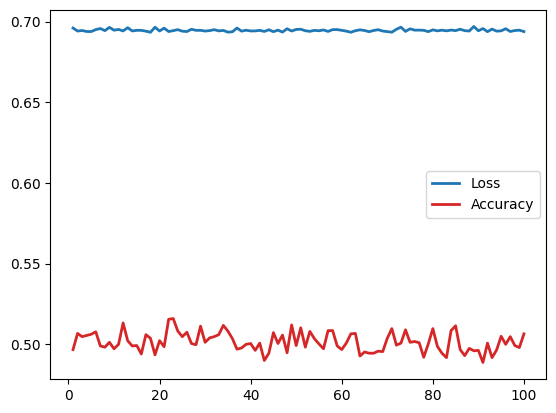

In [ ]:
gate_based_model=amplitude_encoding_simple(nunum_features=2,num_layers=10,measurement_strategy=ML.MeasurementStrategy.PROBABILITIES,num_classes=2)

gate_based_model, accuracy_per_epoch, loss_per_epoch=basic_model_training(gate_based_model,fig3_dataloader,num_epochs=100)

epochs=[i for i in range(1,101)]
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()

### Angle encoding MerLin model

For angle encoding models, the data needs to be normalized to apply meaningful phase shifts. Let's use the `utils`' `normalize_features` function to do so. In the function, we just need to pass the dataset, and then indicate the lowest and highest value of the class. 

This model needs the number of features in input. It is possible to change the number of layers in the circuit, the measurement strategy for a different output and, if necessary, change the ouptut dimension (to fit with the number of classes) with num_classes.

Epoch 1 had a loss of 0.63818519115448 and accuracy of 0.7765
Epoch 2 had a loss of 0.6341165646910667 and accuracy of 0.772
Epoch 3 had a loss of 0.6330718874931336 and accuracy of 0.7765
Epoch 4 had a loss of 0.6333903640508651 and accuracy of 0.79425
Epoch 5 had a loss of 0.6334273390471935 and accuracy of 0.75725
Epoch 6 had a loss of 0.6348564259707927 and accuracy of 0.74
Epoch 7 had a loss of 0.6325727634131908 and accuracy of 0.79675
Epoch 8 had a loss of 0.6334709838032723 and accuracy of 0.786
Epoch 9 had a loss of 0.6329105839133262 and accuracy of 0.79925
Epoch 10 had a loss of 0.6338411219418049 and accuracy of 0.7625
Epoch 11 had a loss of 0.6323660880327224 and accuracy of 0.78875
Epoch 12 had a loss of 0.6328110717236995 and accuracy of 0.795
Epoch 13 had a loss of 0.6334621980786324 and accuracy of 0.7965
Epoch 14 had a loss of 0.6325384333729744 and accuracy of 0.76225
Epoch 15 had a loss of 0.6331764064729214 and accuracy of 0.78875
Epoch 16 had a loss of 0.633040853

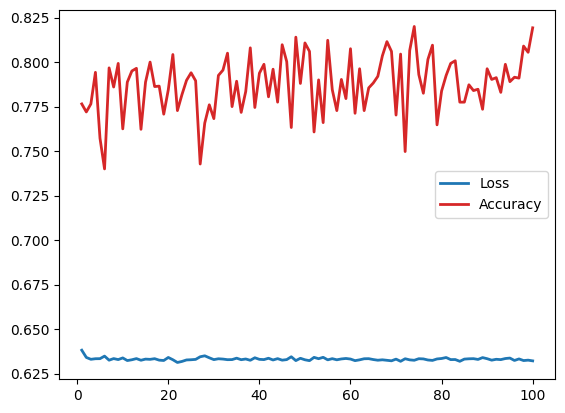

In [ ]:
fig3_dataset=generate_fig_3_dataset()
fig3_dataset_norm=normalize_features(fig3_dataset,[-3, -5], [3, 5])
fig3_dataloader=get_data_loader(fig3_dataset_norm,batch_size=50)

gate_based_model=angle_encoding_simple(num_features=2,num_layers=10,measurement_strategy=ML.MeasurementStrategy.PROBABILITIES,num_classes=2)

gate_based_model, accuracy_per_epoch, loss_per_epoch=basic_model_training(gate_based_model,fig3_dataloader,num_epochs=100)

epochs=[i for i in range(1,101)]
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()

We can see here that the angle encoding model is more suited to classify this synthetic dataset.

Even though the amplitude encoding principle uses less resources, it is not always better than a traditional angle encoding.

## 2. Binary MNIST classification

We will use the binary MNIST classification to demonstrate how to use the two photonic QCNN available in this repository.

First, we need to load the dataset using the following functions implemented in the `utils`.

In [38]:
mnist_dataset=get_binary_dataset(name="MNIST",num_samples_per_class=100)[0]

The `get_binary_dataset` function can also load the CIFAR-10 (birds and planes), EuroSAT (sea lakes and trees) and PathMNIST (adipose tissues and background) binary dataset. Just change the docstring name to get them.

In [39]:
mnist_loader=get_data_loader(mnist_dataset,batch_size=25)

### Gate-based QCNN

This model was implemented via Hanrui Wang's [torchquantum](https://github.com/mit-han-lab/torchquantum) repository. 

It follows the exact structure shown in the paper.

We can define the number of qubits needed in the model ($\lceil \log_2 (\text{num\_features})\rceil$) and if to return logits instead of state probabilities as the forward's output.

Epoch 1 had a loss of 0.6894953101873398 and accuracy of 0.5
Epoch 2 had a loss of 0.6744652986526489 and accuracy of 0.585
Epoch 3 had a loss of 0.6657849475741386 and accuracy of 0.585
Epoch 4 had a loss of 0.6614372059702873 and accuracy of 0.635
Epoch 5 had a loss of 0.656427301466465 and accuracy of 0.705
Epoch 6 had a loss of 0.6544233858585358 and accuracy of 0.74
Epoch 7 had a loss of 0.6514071971178055 and accuracy of 0.78
Epoch 8 had a loss of 0.6506006494164467 and accuracy of 0.85
Epoch 9 had a loss of 0.6499649956822395 and accuracy of 0.86
Epoch 10 had a loss of 0.6492297351360321 and accuracy of 0.84


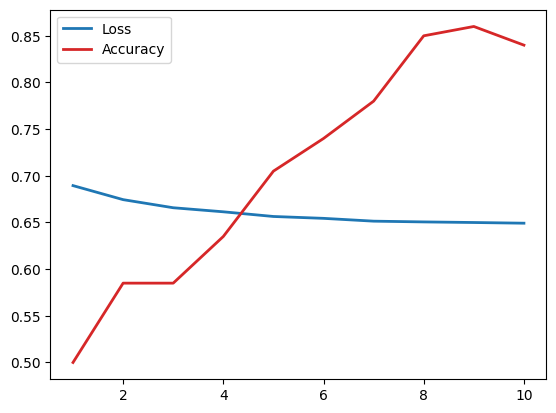

In [40]:
gate_based_model=qiskit_QCNN(num_qubits=10)

gate_based_model, accuracy_per_epoch, loss_per_epoch=basic_model_training(gate_based_model,mnist_loader,num_epochs=10)

epochs=[i for i in range(1,11)]
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()

### MerLin QCNN

This model was the one presented in [photonic_QCNN](../photonic_QCNN/) reproduced paper as the `HybridModel`. We renamed it in this repository as `PhotonicQCNN`. To get more information on this model. consult the repository.

In [ ]:
merlin_model=PhotonicQCNN(
    dims=(32, 32),
    conv_circuit="MZI",
    dense_circuit="MZI",
    dense_added_modes=0,
    output_proba_type="state",
    output_formatting="Lex_grouping",
    num_classes=2,
    measure_subset=None,
)

merlin_model, accuracy_per_epoch, loss_per_epoch=basic_model_training(merlin_model,mnist_loader,num_epochs=10)

epochs=[i for i in range(1,11)]
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()

Number of Fock states: 528
Epoch 1 had a loss of 1.7764797061681747 and accuracy of 0.585
Epoch 2 had a loss of 0.48743926733732224 and accuracy of 0.79
Epoch 3 had a loss of 0.3155384138226509 and accuracy of 0.89


The MNIST model is known to be well classified with those models. It is now time to explore the limitations of the approach with the other datasets!